<center><h1><b>ANALYSIS OF CUTS ON MC</b></h1></center>

In this notebook we want to search for the best cuts of the Monte Carlo data

The codes in the pdg are:

$$
\begin{align}
D^0 \rightarrow K^- \quad \pi^+ \\
421 \rightarrow -321 \quad211
\end{align}
$$


$$
\begin{align}
\overline{D^0} \rightarrow& \quad K^+ \qquad \pi^- \\
-421 \rightarrow& +321 \quad-211
\end{align}
$$

In [41]:
import numpy as np
import pandas as pd
import awkward as ak
import uproot
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from IPython.display import Image, display
import os
from scipy.optimize import curve_fit
from scipy.stats import norm

import gc
import itertools

# Particle masses in GeV
m_K = 0.493677
m_pi = 0.139570
m_d0 = 1.86484

---

# UPLOADING DATA

#### ALL OUR DATA

In [2]:
%%bash
ls "/home/benedetto/Scrivania/LCP_B/project/df_pairs_all_variabs"

mc_pairs_001_010_pt1.pkl
mc_pairs_001_010_pt2.pkl
mc_pairs_001_010_pt3.pkl
mc_pairs_011_020_pt1.pkl
mc_pairs_011_020_pt2.pkl
mc_pairs_011_020_pt3.pkl
mc_pairs_011_020_pt4.pkl
mc_pairs_011_020_pt5.pkl
mc_pairs_011_020_pt6.pkl
mc_pairs_021_030_pt1.pkl
mc_pairs_021_030_pt2.pkl
mc_pairs_021_030_pt3.pkl
mc_pairs_021_030_pt4.pkl
mc_pairs_021_030_pt5.pkl
mc_pairs_031_040_pt1.pkl
mc_pairs_031_040_pt2.pkl
mc_pairs_031_040_pt3.pkl
mc_pairs_031_040_pt4.pkl
mc_pairs_031_040_pt5.pkl
mc_pairs_041_050_pt1.pkl
mc_pairs_041_050_pt2.pkl
mc_pairs_041_050_pt3.pkl
mc_pairs_041_050_pt4.pkl
mc_pairs_041_050_pt5.pkl
mc_pairs_16_09.pkl


#### CHOSEN FILES

In [3]:
# list of all files to load
files = [
    "mc_pairs_001_010_pt1.pkl",
    "mc_pairs_001_010_pt2.pkl",
    "mc_pairs_001_010_pt3.pkl",
    "mc_pairs_011_020_pt1.pkl",
    "mc_pairs_011_020_pt2.pkl",
    "mc_pairs_011_020_pt3.pkl",
    "mc_pairs_011_020_pt4.pkl",
    "mc_pairs_011_020_pt5.pkl",
    "mc_pairs_011_020_pt6.pkl",
    "mc_pairs_021_030_pt1.pkl",
    "mc_pairs_021_030_pt2.pkl",
    "mc_pairs_021_030_pt3.pkl",
    "mc_pairs_021_030_pt4.pkl",
    "mc_pairs_021_030_pt5.pkl",
    "mc_pairs_031_040_pt1.pkl",
    "mc_pairs_031_040_pt2.pkl",
    "mc_pairs_031_040_pt3.pkl",
    # "mc_pairs_031_040_pt4.pkl",
    # "mc_pairs_031_040_pt5.pkl",
    # "mc_pairs_041_050_pt1.pkl",
    # "mc_pairs_041_050_pt2.pkl",
    # "mc_pairs_041_050_pt3.pkl",
    # "mc_pairs_041_050_pt4.pkl",
    # "mc_pairs_041_050_pt5.pkl",
]

#### UPLOAD DATA

In [4]:
# directory where the files are stored
data_dir = "/home/benedetto/Scrivania/LCP_B/project/df_pairs_all_variabs"

# load each pickle into a DataFrame
final_results = []
for f in files:
    full_path = os.path.join(data_dir, f)
    df = pd.read_pickle(full_path)
    final_results.append(df)
    del df
print(f"Loaded {len(files)} files.")

# concatenate all DataFrames into one
final_results = pd.concat(final_results, ignore_index=True)

Loaded 17 files.


In [5]:
print(f"The uploaded dataframe has {len(final_results):_} rows and {len(final_results.columns):_} columns.")
memory = final_results.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"It occupies {memory:_.2f} MB")

display( pd.concat([final_results.head(5),final_results.tail(5)]) )

The uploaded dataframe has 28_585_297 rows and 24 columns.
It occupies 5_234.12 MB


,dcaXY_product,inv_mass,anti_mass,pt,decay_length,cos_pointing,neg_pt,neg_TPCka,neg_TOFka,neg_fDcaXY,...,track_pdg_pos,track_pdg_neg,mother_pdg_pos,mother_pdg_neg,beauty_pdg_pos,beauty_pdg_neg,mother_N_final_state_pos,mother_N_final_state_neg,mother_orig_ind_pos,mother_orig_ind_neg
0,4.302637e-05,1.078002,0.965592,2.071664,0.008672,0.541366,0.818927,-1.574181,-21.357477,-0.005362,...,211.0,-211.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0
1,-2.267289e-05,0.954106,0.976759,1.351086,0.017328,0.987720,0.818927,-1.574181,-21.357477,-0.005362,...,211.0,-211.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0
2,-4.802854e-05,1.533463,1.549260,0.686016,6.203392,-0.249098,0.818927,-1.574181,-21.357477,-0.005362,...,211.0,-211.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0
3,-4.880044e-07,1.353739,1.423982,0.511211,0.009233,-0.387148,0.818927,-1.574181,-21.357477,-0.005362,...,211.0,-211.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0
4,3.675097e-05,1.292375,1.360894,0.652137,0.015217,-0.390342,0.818927,-1.574181,-21.357477,-0.005362,...,211.0,-211.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0
28585292,5.258937e-02,0.666448,0.806590,0.842768,2.566516,0.629973,0.541465,-4.766050,-999.000000,-0.200726,...,321.0,-211.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0
28585293,3.713347e-02,0.883208,0.896981,1.166228,2.448712,0.298682,0.541465,-4.766050,-999.000000,-0.200726,...,211.0,-211.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0
28585294,4.271557e-02,0.819857,0.892104,1.001889,1.464870,0.204777,0.541465,-4.766050,-999.000000,-0.200726,...,321.0,-211.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0
28585295,5.897032e-03,1.522838,1.426583,0.619172,0.513109,-0.411187,0.473849,-6.739955,-999.000000,-0.021349,...,211.0,-211.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0
28585296,2.728765e-02,1.525444,1.396462,0.978039,3.265037,-0.391168,0.343846,-8.423986,-999.000000,-0.098791,...,211.0,-211.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0


## TRUE $D_0$ IN OUR DATA

In [6]:
mask_true_d0 = (
    (final_results["track_pdg_pos"] == 211 ) &
    (final_results["track_pdg_neg"] == -321 ) &
    (final_results["mother_pdg_pos"] == 421) &
    (final_results["mother_pdg_neg"] == 421) &
    (final_results["beauty_pdg_pos"] == 0) &
    (final_results["beauty_pdg_neg"] == 0) &
    (final_results["mother_N_final_state_pos"] == 2) &
    (final_results["mother_N_final_state_neg"] == 2)
)
mask_true_anti_d0 = (
    (final_results["track_pdg_pos"] == 321) &
    (final_results["track_pdg_neg"] == -211) &
    (final_results["mother_pdg_pos"] == -421) &
    (final_results["mother_pdg_neg"] == -421) &
    (final_results["beauty_pdg_pos"] == 0) &
    (final_results["beauty_pdg_neg"] == 0) &
    (final_results["mother_N_final_state_pos"] == 2) &
    (final_results["mother_N_final_state_neg"] == 2)
)

In [7]:
d0_tot = np.sum( mask_true_d0 )
anti_d0_tot = np.sum( mask_true_anti_d0 )
print("Number of D0:      ", d0_tot )
print("Number of anti-D0: ", anti_d0_tot )
print("Rest:              ", len(final_results)-d0_tot-anti_d0_tot )
print(f"Fraction of D0 and anti-D0 over total: {(d0_tot+anti_d0_tot)/len(final_results) * 100:.4f}%"  )

Number of D0:       6345
Number of anti-D0:  6757
Rest:               28572195
Fraction of D0 and anti-D0 over total: 0.0458%


The variables we have to work with are:

In [8]:
print(final_results.columns)

Index(['dcaXY_product', 'inv_mass', 'anti_mass', 'pt', 'decay_length',
       'cos_pointing', 'neg_pt', 'neg_TPCka', 'neg_TOFka', 'neg_fDcaXY',
       'pos_pt', 'pos_TPCpi', 'pos_TOFpi', 'pos_fDcaXY', 'track_pdg_pos',
       'track_pdg_neg', 'mother_pdg_pos', 'mother_pdg_neg', 'beauty_pdg_pos',
       'beauty_pdg_neg', 'mother_N_final_state_pos',
       'mother_N_final_state_neg', 'mother_orig_ind_pos',
       'mother_orig_ind_neg'],
      dtype='object')


Example: the variable 'neg_TOFka' means the TOF in the Kaon hypothesis, i.e. the time of flight expressed in how many sigma we are away from the mean of the typical Kaon flight. The 'neg' refers to the fact that this is measured for the negative track particle, which is a $K^-$ for the $D_0$ case, a $\pi^-$ for the $anti-D_0$ case, and something else in background case.

---

---

# INVARIANT MASS
We now plot the data, remembering to plot both the columns for mass and anti-mass.

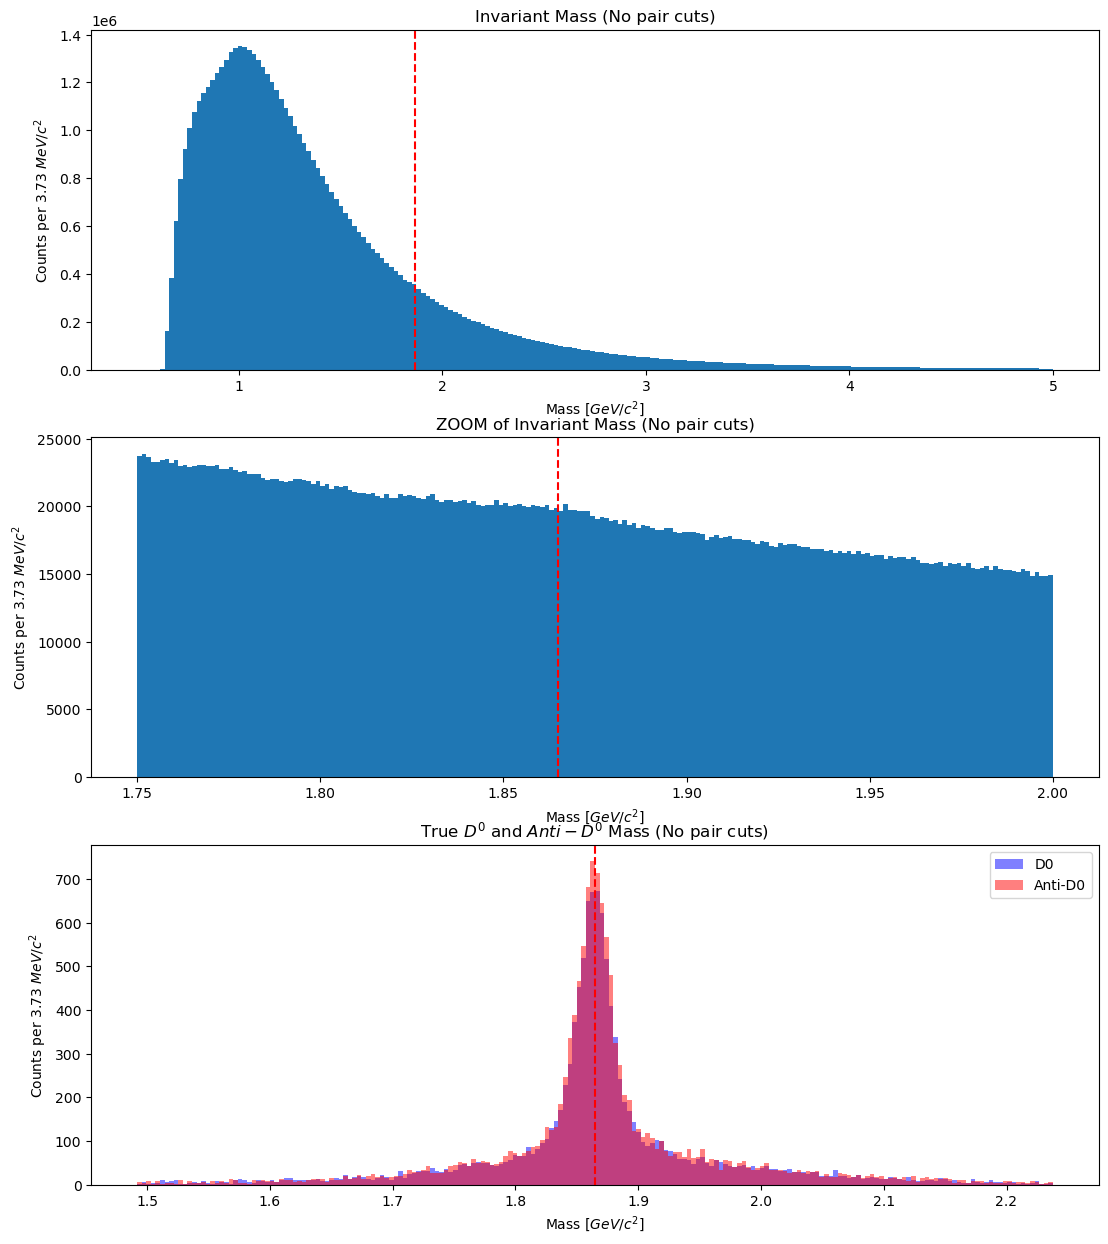

In [9]:
MIN_MASS, MAX_MASS = 0.80*m_d0, 1.20*m_d0
N_BINS = 200

num_of_plots = 3
fig, axs = plt.subplots( num_of_plots, 1, figsize=(13,5*num_of_plots)  )

# GLOBAL PLOT
data = np.concatenate( [final_results["inv_mass"].values, final_results["anti_mass"].values])
axs[0].hist( data, bins=N_BINS, range=(0.5, 5))
axs[0].axvline(x=m_d0, color="red", ls='--')
axs[0].set_xlabel("Mass [$GeV/c^2$]")
axs[0].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
axs[0].set_title("Invariant Mass (No pair cuts)")
#axs[0].set_xticks( np.arange(0, 8) )

# ZOOM OF GLOBAL PLOT
data = np.concatenate( [final_results["inv_mass"].values, final_results["anti_mass"].values] )
axs[1].hist( data, bins=N_BINS, range=(1.75, 2))
axs[1].axvline(x=m_d0, color="red", ls='--')
axs[1].set_xlabel("Mass [$GeV/c^2$]")
axs[1].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
axs[1].set_title("ZOOM of Invariant Mass (No pair cuts)")
#axs[1].set_xticks( np.arange(0, 8) )

# PLOTTING TRUE D0 and TRUE anti-D0 FROM MC INFO
data = np.concatenate([ final_results.loc[mask_true_d0, "inv_mass"].values, final_results.loc[mask_true_d0, "anti_mass"].values ])
axs[2].hist( data , bins=N_BINS, range=(MIN_MASS, MAX_MASS), color="blue", alpha=0.5, label="D0")
data = np.concatenate([final_results.loc[mask_true_anti_d0, "inv_mass"].values, final_results.loc[mask_true_anti_d0, "anti_mass"].values])
axs[2].hist( data , bins=N_BINS, range=(MIN_MASS, MAX_MASS), color="red", alpha=0.5, label="Anti-D0")
axs[2].axvline(x=m_d0, color="red", ls='--')
axs[2].set_xlabel("Mass [$GeV/c^2$]")
axs[2].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
axs[2].set_title("True $D^0$ and $Anti-D^0$ Mass (No pair cuts)")
axs[2].legend()
#axs[2].set_xticks( np.arange(1.6, 2.2, 0.05) )

del data
#plt.savefig("D0_Mass_MC.png")
plt.show()

From the plot above we can see that the width of the mass peak is around $1.80-1.93$ $MeV/c^2$. So during the search for the $D_0$ in real data we can focus in this interval.  

Also the distribution of $D_0$ and $anti-D_0$ is almost the same.

---

---

# VARIABLES DISTRIBUTION
Let's study the distribution of the variables for the known correct tracks. In this way we can do better cuts.

### $\pi$ TRACKS
Let's observe the distribution of the variables for the $\pi$ tracks, for both the known $D_0$ and also for all the combinatory background.

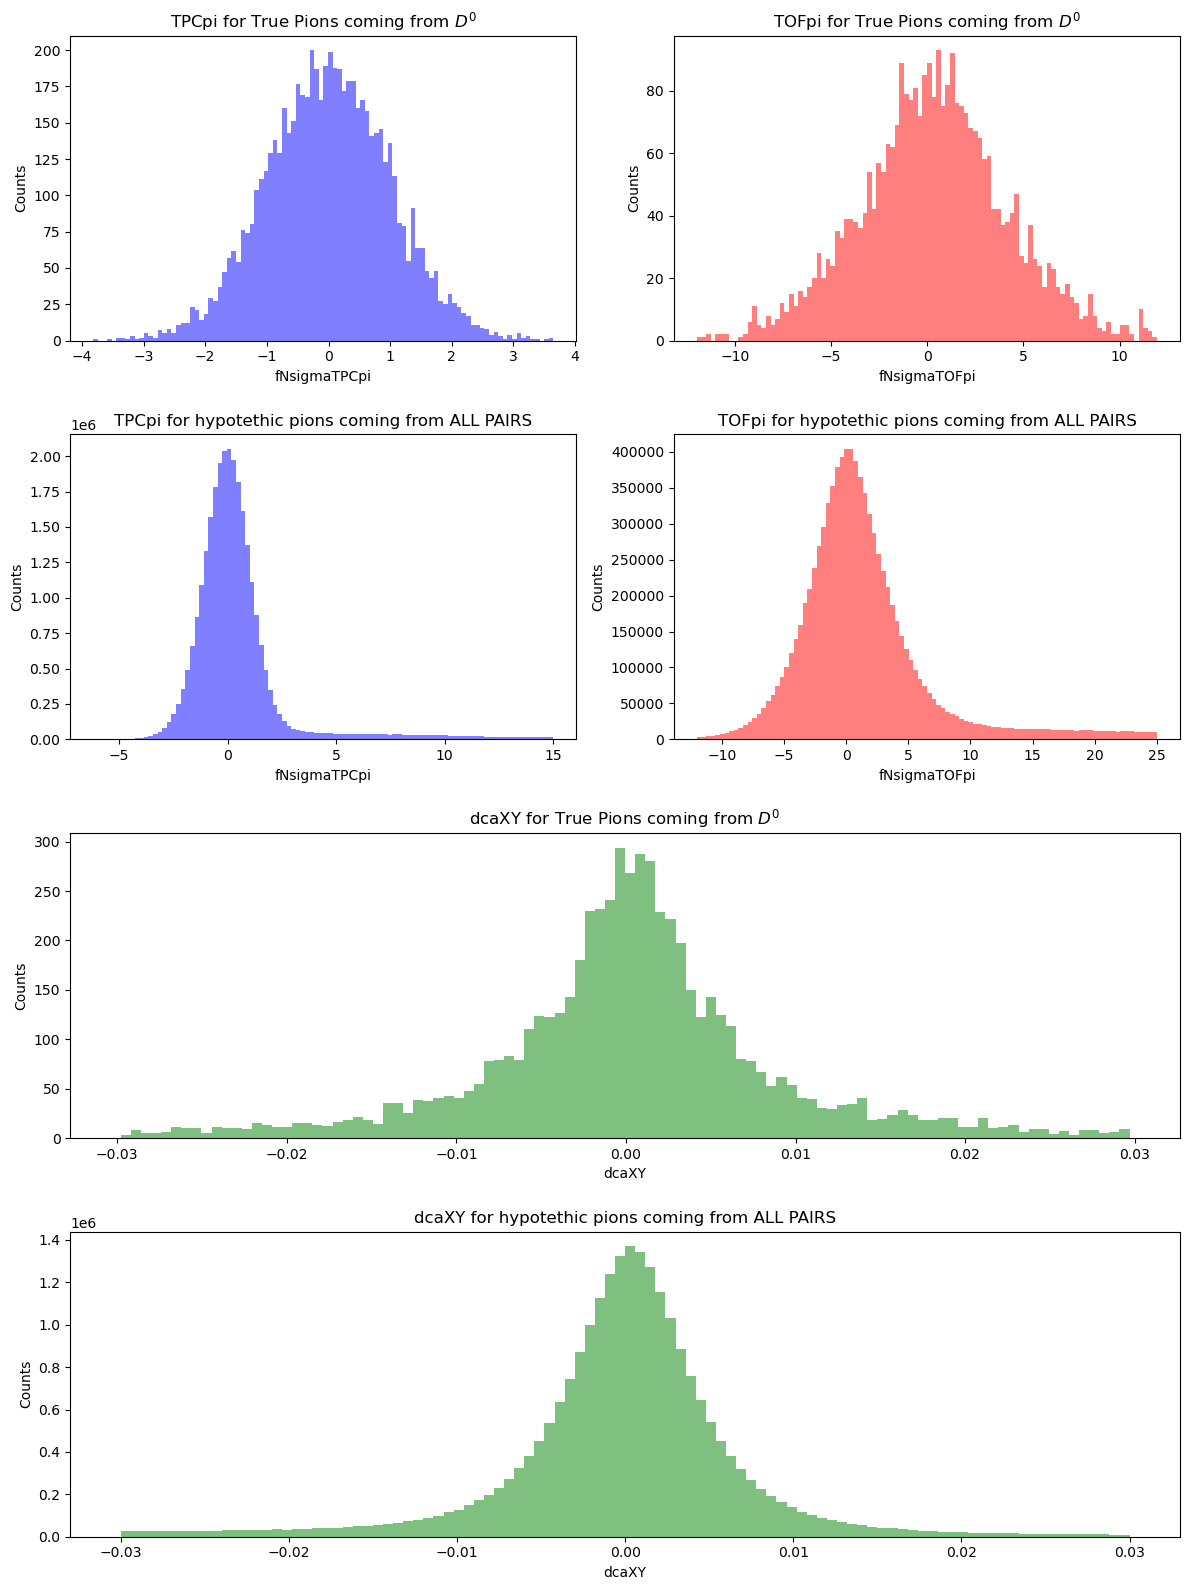

In [22]:
N_BINS = 100

# Layout con due colonne
zones = [
    ["tpcpi_D0", "tofpi_D0"],
    ["tpcpi_all", "tofpi_all"],
    ["dcaxy_D0","dcaxy_D0"],
    ["dcaxy_all","dcaxy_all"],
]

# Creazione della figura usando subplot_mosaic
fig, axes = plt.subplot_mosaic(
    zones,
    figsize=(12, 16)
)

# --- Plot TPCpi for TRUE D0 ---
data = final_results.loc[mask_true_d0, 'pos_TPCpi'].values
axes["tpcpi_D0"].hist(data, bins=N_BINS, color="blue", alpha=0.5, label="D^0")
axes["tpcpi_D0"].set_title("TPCpi for True Pions coming from $D^0$")
axes["tpcpi_D0"].set_xlabel("fNsigmaTPCpi")
axes["tpcpi_D0"].set_ylabel("Counts")

# --- Plot TOFpi con filtro (-12, 12) for TRUE D0 ---
data = final_results.loc[mask_true_d0, 'pos_TOFpi'].values
data = data[(data > -12) & (data < 12)]
axes["tofpi_D0"].hist(data, bins=N_BINS, color="red", alpha=0.5, label="D^0")
axes["tofpi_D0"].set_title("TOFpi for True Pions coming from $D^0$")
axes["tofpi_D0"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_D0"].set_ylabel("Counts")

# --- Plot TPCpi FOR ALL PAIRS---
data = final_results['pos_TPCpi'].values
data = data[(data > -7) & (data < 15)]
axes["tpcpi_all"].hist(data, bins=N_BINS, color="blue", alpha=0.5, label="D^0")
axes["tpcpi_all"].set_title("TPCpi for hypotethic pions coming from ALL PAIRS")
axes["tpcpi_all"].set_xlabel("fNsigmaTPCpi")
axes["tpcpi_all"].set_ylabel("Counts")

# --- Plot TOFpi con filtro (-12, 12) FOR ALL PAIRS ---
data = final_results['pos_TOFpi'].values
data = data[(data > -12) & (data < 25)]
axes["tofpi_all"].hist(data, bins=N_BINS, color="red", alpha=0.5, label="D^0")
axes["tofpi_all"].set_title("TOFpi for hypotethic pions coming from ALL PAIRS")
axes["tofpi_all"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_all"].set_ylabel("Counts")

# --- Plot dcaXY for TRUE D0 ---
data = final_results.loc[mask_true_d0, 'pos_fDcaXY'].values
data = data[(data > -0.03) & (data < 0.03)]
axes["dcaxy_D0"].hist(data, bins=N_BINS, color="green", alpha=0.5, label=f"D^0")
axes["dcaxy_D0"].set_title("dcaXY for True Pions coming from $D^0$")
axes["dcaxy_D0"].set_xlabel("dcaXY")
axes["dcaxy_D0"].set_ylabel("Counts")

# --- Plot dcaXY FOR ALL PAIRS ---
data = final_results['pos_fDcaXY'].values
data = data[(data > -0.03) & (data < 0.03)]
axes["dcaxy_all"].hist(data, bins=N_BINS, color="green", alpha=0.5, label=f"D^0")
axes["dcaxy_all"].set_title("dcaXY for hypotethic pions coming from ALL PAIRS")
axes["dcaxy_all"].set_xlabel("dcaXY")
axes["dcaxy_all"].set_ylabel("Counts")

plt.tight_layout()
plt.show()

del data


Sadly, they are all too similar.

### $K$ TRACKS
Let's observe the distribution of the variables for the $Kaons$ tracks, for both the known $D_0$ and also for all the combinatory background.

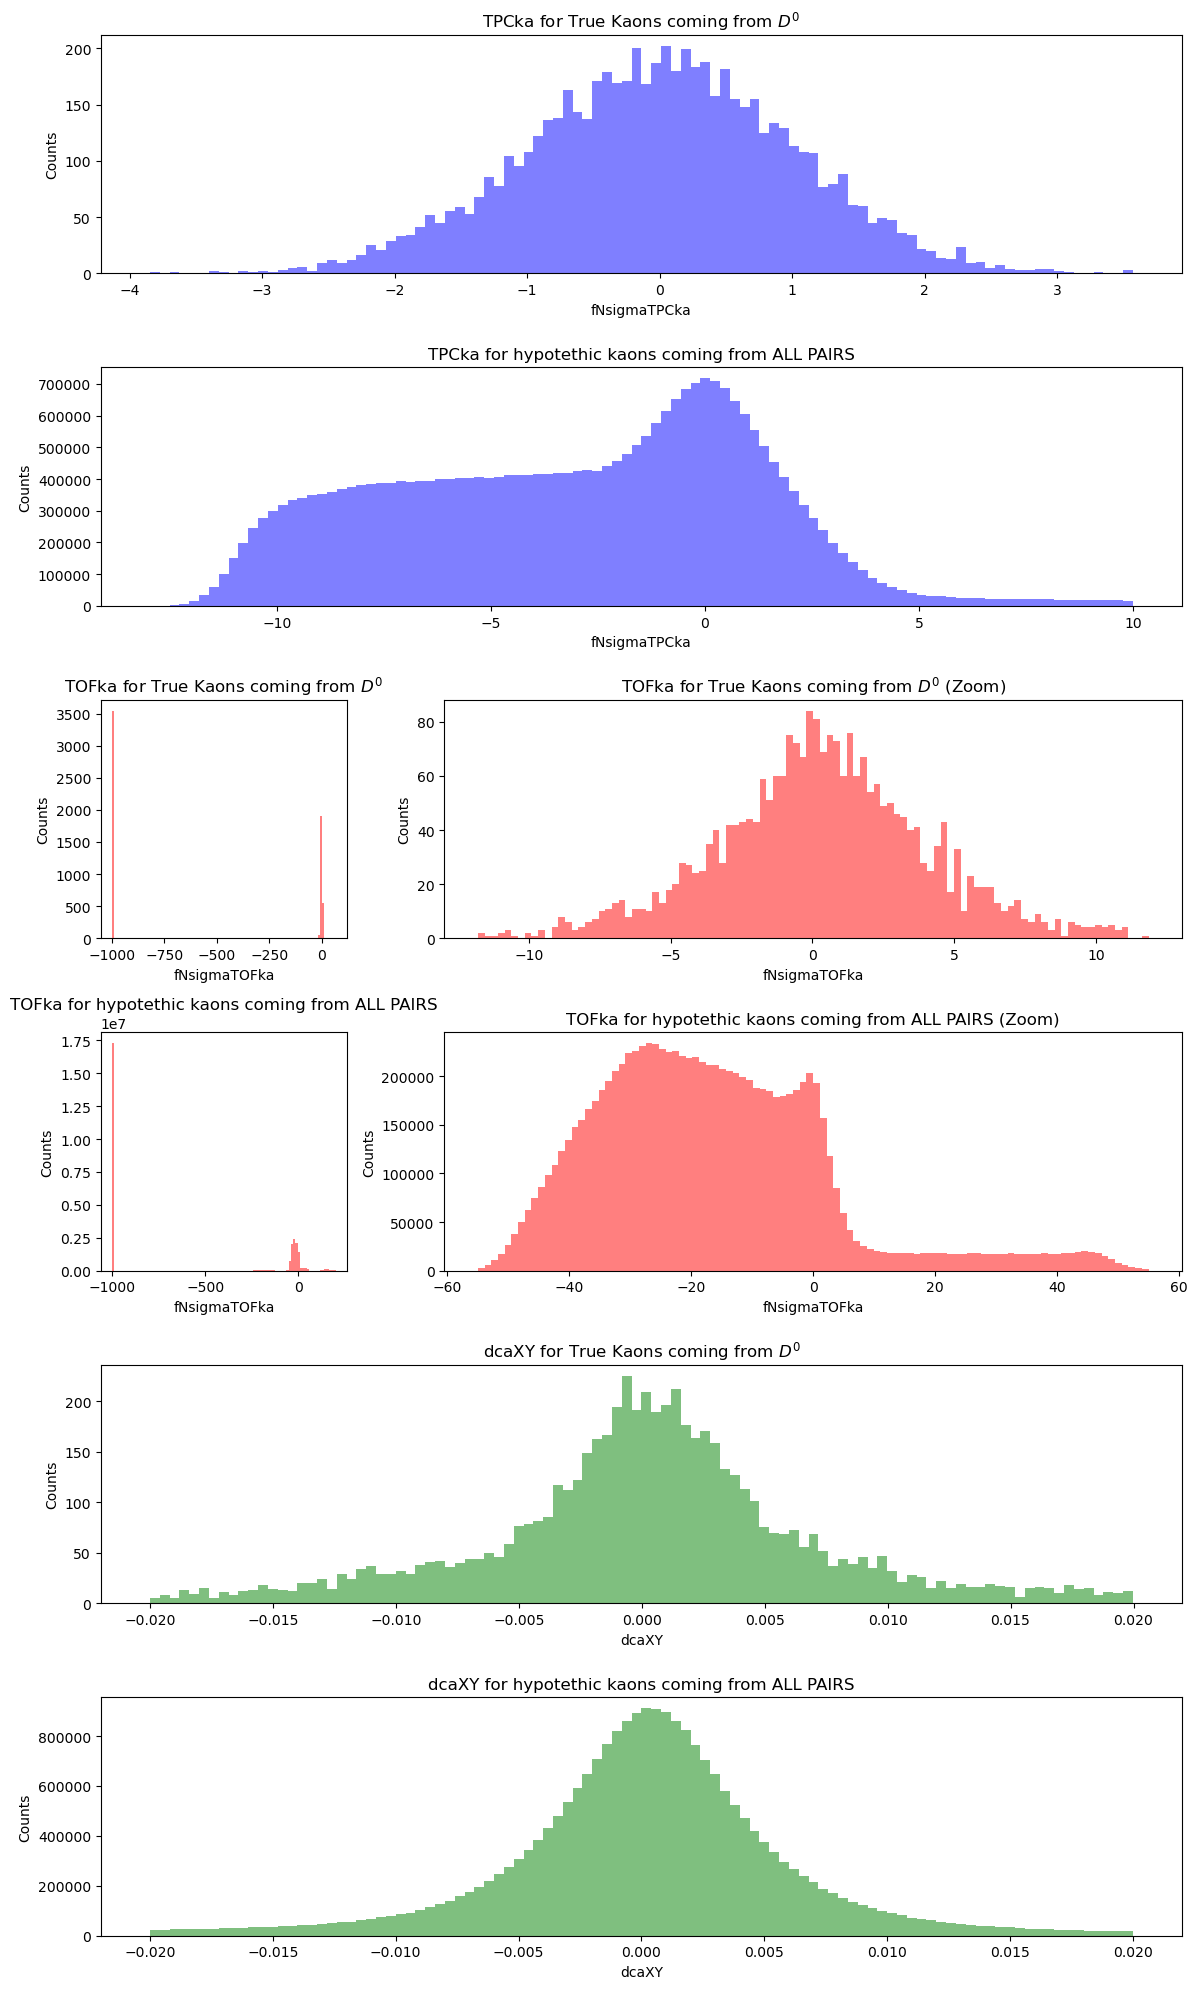

In [11]:
N_BINS = 100

# zones for the plots:
zones = [
    ["tpcka_D0", "tpcka_D0"],
    ["tpcka_all", "tpcka_all"],
    ["tofka_D0", "tofka_zoom_D0"],
    ["tofka_all", "tofka_zoom_all"],
    ["dcaxy_D0","dcaxy_D0"],
    ["dcaxy_all","dcaxy_all"]
]

# Creazione della figura con proporzioni personalizzate
fig, axes = plt.subplot_mosaic(
    zones,
    figsize=(12, 20),
    gridspec_kw={"width_ratios": [1, 3]}
)

# --- Plot TPCka FOR TRUE D0---
data = final_results.loc[mask_true_d0, 'neg_TPCka'].values
axes["tpcka_D0"].hist(data, bins=N_BINS, color="blue", alpha=0.5, label=f"D^0")
axes["tpcka_D0"].set_title("TPCka for True Kaons coming from $D^0$")
axes["tpcka_D0"].set_xlabel("fNsigmaTPCka")
axes["tpcka_D0"].set_ylabel("Counts")

# --- Plot TPCka FOR ALL PAIRS---
data = final_results['neg_TPCka'].values
data = data[(data > -13) & (data < 10)]
axes["tpcka_all"].hist(data, bins=N_BINS, color="blue", alpha=0.5, label=f"D^0")
axes["tpcka_all"].set_title("TPCka for hypotethic kaons coming from ALL PAIRS")
axes["tpcka_all"].set_xlabel("fNsigmaTPCka")
axes["tpcka_all"].set_ylabel("Counts")

# --- Plot TOFka completo FOR TRUE D0 ---
data = final_results.loc[mask_true_d0, 'neg_TOFka'].values
data = data[(data > -1000) & (data < 100)]
axes["tofka_D0"].hist(data, bins=N_BINS, color="red", alpha=0.5, label=f"D^0")
axes["tofka_D0"].set_title("TOFka for True Kaons coming from $D^0$")
axes["tofka_D0"].set_xlabel("fNsigmaTOFka")
axes["tofka_D0"].set_ylabel("Counts")

# --- Plot TOFka zoom (-12,12) FOR TRUE D0 ---
data_zoom = data[(data > -12) & (data < 12)]
axes["tofka_zoom_D0"].hist(data_zoom, bins=N_BINS, color="red", alpha=0.5, label=f"D^0")
axes["tofka_zoom_D0"].set_title("TOFka for True Kaons coming from $D^0$ (Zoom)")
axes["tofka_zoom_D0"].set_xlabel("fNsigmaTOFka")
axes["tofka_zoom_D0"].set_ylabel("Counts")

# --- Plot TOFka completo FOR ALL PAIRS ---
data = final_results['neg_TOFka'].values
data = data[(data > -1000) & (data < 200)]
axes["tofka_all"].hist(data, bins=N_BINS, color="red", alpha=0.5, label=f"D^0")
axes["tofka_all"].set_title("TOFka for hypotethic kaons coming from ALL PAIRS")
axes["tofka_all"].set_xlabel("fNsigmaTOFka")
axes["tofka_all"].set_ylabel("Counts")

# --- Plot TOFka zoom (-12,12) FOR ALL PAIRS ---
data_zoom = data[(data > -55) & (data < 55)]
axes["tofka_zoom_all"].hist(data_zoom, bins=N_BINS, color="red", alpha=0.5, label=f"D^0")
axes["tofka_zoom_all"].set_title("TOFka for hypotethic kaons coming from ALL PAIRS (Zoom)")
axes["tofka_zoom_all"].set_xlabel("fNsigmaTOFka")
axes["tofka_zoom_all"].set_ylabel("Counts")

# --- Plot dcaXY FOR TRUE D0 ---
data = final_results.loc[mask_true_d0, 'neg_fDcaXY'].values
data = data[(data > -0.02) & (data < 0.02)]
axes["dcaxy_D0"].hist(data, bins=N_BINS, color="green", alpha=0.5, label=f"D^0")
axes["dcaxy_D0"].set_title("dcaXY for True Kaons coming from $D^0$")
axes["dcaxy_D0"].set_xlabel("dcaXY")
axes["dcaxy_D0"].set_ylabel("Counts")

# --- Plot dcaXY FOR ALL PAIRS ---
data = final_results['neg_fDcaXY'].values
data = data[(data > -0.02) & (data < 0.02)]
axes["dcaxy_all"].hist(data, bins=N_BINS, color="green", alpha=0.5, label=f"D^0")
axes["dcaxy_all"].set_title("dcaXY for hypotethic kaons coming from ALL PAIRS")
axes["dcaxy_all"].set_xlabel("dcaXY")
axes["dcaxy_all"].set_ylabel("Counts")

plt.tight_layout()
plt.show()
del data

We can see that the variables TPCka and TOFka can be very useful as cuts. 

But what to do with data at -999 TOF? Let's see.

In [12]:
print(f"Total number of D0: {d0_tot}")
data = final_results.loc[mask_true_d0, 'neg_TOFka'].values
data = data[ (data > -1000) & (data < -998)]
print(f"Fraction of True D0 with TOFka = -999:  {len(data)/d0_tot:.2f}")
print(f"Fraction of True D0 with TOFka != -999: { (d0_tot-len(data)) / d0_tot :.2f} \n")

print(f"Total number of data: {len(final_results)}")
data = final_results['neg_TOFka'].values
data = data[ (data > -1000) & (data < -998)]
print(f"Fraction of all data with TOFka = -999:  {len(data)/len(final_results) :.2f}")
print(f"Fraction of all data with TOFka != -999: { (len(final_results)-len(data)) / len(final_results) :.2f}")
del data

Total number of D0: 6345
Fraction of True D0 with TOFka = -999:  0.56
Fraction of True D0 with TOFka != -999: 0.44 

Total number of data: 28585297
Fraction of all data with TOFka = -999:  0.60
Fraction of all data with TOFka != -999: 0.40


If we keep the data with TOFka=-999, we keep a lot of background.  
Instead if we remove it, yeah we lose 44% of true D0, but we stay in a zone where our cut is effective (see red plot above). So cutting away TOFka=-999 could be a good choice.

### POYNTING ANGLE

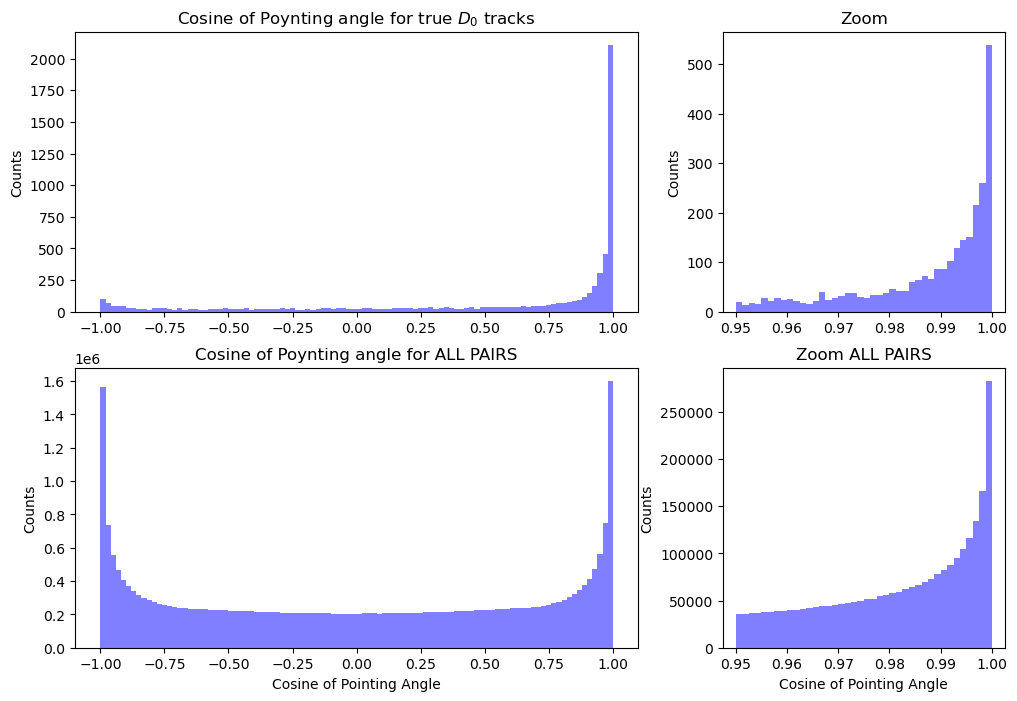

With the cut at 0.95 we keep 41687.93% of original D_0s


In [13]:
N_BINS = 100

# Layout con due colonne
zones = [
    ["total_D0", "zoom_D0"],
    ["total_all", "zoom_all"],
]

# Creazione della figura usando subplot_mosaic
fig, axes = plt.subplot_mosaic(
    zones,
    figsize=(12, 8),
    gridspec_kw={"width_ratios": [2, 1]}
)

# --- Plot cosine of poynting angle FOR TRUE D0 ---
data = final_results.loc[mask_true_d0, 'cos_pointing'].values
axes["total_D0"].hist( data, bins=N_BINS, color="blue", alpha=0.5, label=f"D^0")
axes["total_D0"].set_ylabel("Counts")
axes["total_D0"].set_title("Cosine of Poynting angle for true $D_0$ tracks")

# --- Zoom FOR TRUE D0 ---
cut = 0.95
data = data[ data > cut ]
axes["zoom_D0"].hist( data, bins=40, color="blue", alpha=0.5, label=f"D^0")
axes["zoom_D0"].set_ylabel("Counts")
axes["zoom_D0"].set_title("Zoom")

# --- Plot cosine of poynting angle FOR ALL PAIRS ---
data = final_results['cos_pointing'].values
axes["total_all"].hist( data, bins=N_BINS, color="blue", alpha=0.5, label=f"D^0")
axes["total_all"].set_ylabel("Counts")
axes["total_all"].set_xlabel("Cosine of Pointing Angle")
axes["total_all"].set_title("Cosine of Poynting angle for ALL PAIRS")

# --- Zoom FOR ALL PAIRS ---
cut = 0.95
data = data[ data > cut ]
axes["zoom_all"].hist( data, bins=40, color="blue", alpha=0.5, label=f"D^0")
axes["zoom_all"].set_ylabel("Counts")
axes["zoom_all"].set_xlabel("Cosine of Pointing Angle")
axes["zoom_all"].set_title("Zoom ALL PAIRS")

plt.show()

print(f"With the cut at {cut} we keep {len(data)/d0_tot*100:.2f}% of original D_0s")
del data

Sadly, the two distributions are verys similar.

#### dcaXY PRODUCT

With the cut at 2e-05 we keep 57.18% of original D_0s


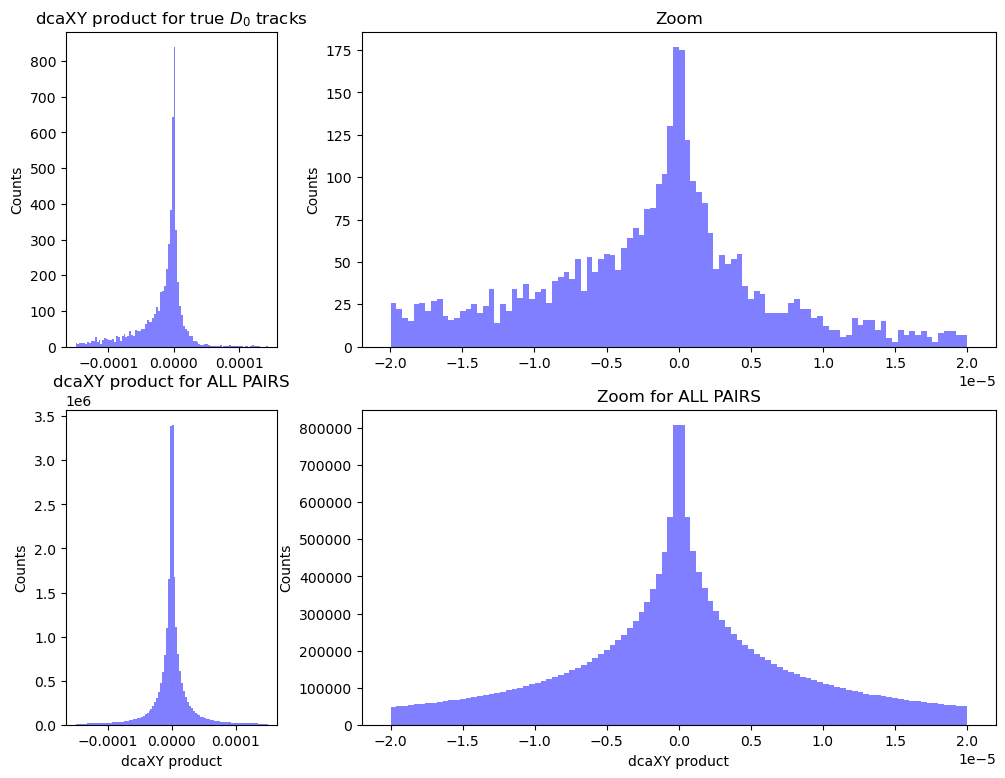

In [14]:
N_BINS = 100

# Layout con due colonne
zones = [
    ["total_D0", "zoom_D0"],
    ["total_all", "zoom_all"],
]

# Creazione della figura usando subplot_mosaic
fig, axes = plt.subplot_mosaic(
    zones,
    figsize=(12, 9),
    gridspec_kw={"width_ratios": [1, 3]}
)

# --- Plot dcaCY product FOR TRUE D0 ---
data = final_results.loc[mask_true_d0, 'dcaXY_product'].values
data = data[ (data > -0.00015) & (data < 0.00015) ]
axes["total_D0"].hist( data, bins=N_BINS, color="blue", alpha=0.5, label=f"D^0")
axes["total_D0"].set_ylabel("Counts")
axes["total_D0"].set_title("dcaXY product for true $D_0$ tracks")

# --- Zoom FOR TRUE D0 ---
cut = 0.00002
data = data[ (data > -cut) & (data < cut) ]
axes["zoom_D0"].hist( data, bins=100, color="blue", alpha=0.5, label=f"D^0")
axes["zoom_D0"].set_ylabel("Counts")
axes["zoom_D0"].set_title("Zoom")
print(f"With the cut at {cut} we keep {len(data)/d0_tot*100:.2f}% of original D_0s")

# --- Plot dcaCY product FOR ALL PAIRS ---
data = final_results['dcaXY_product'].values
data = data[ (data > -0.00015) & (data < 0.00015) ]
axes["total_all"].hist( data, bins=N_BINS, color="blue", alpha=0.5, label=f"D^0")
axes["total_all"].set_ylabel("Counts")
axes["total_all"].set_xlabel("dcaXY product")
axes["total_all"].set_title("dcaXY product for ALL PAIRS")

# --- Zoom FOR ALL PAIRS ---
cut = 0.00002
data = data[ (data > -cut) & (data < cut) ]
axes["zoom_all"].hist( data, bins=100, color="blue", alpha=0.5, label=f"D^0")
axes["zoom_all"].set_ylabel("Counts")
axes["zoom_all"].set_xlabel("dcaXY product")
axes["zoom_all"].set_title("Zoom for ALL PAIRS")

plt.show()
del data

#### $p_T$ DISTRIBUTION

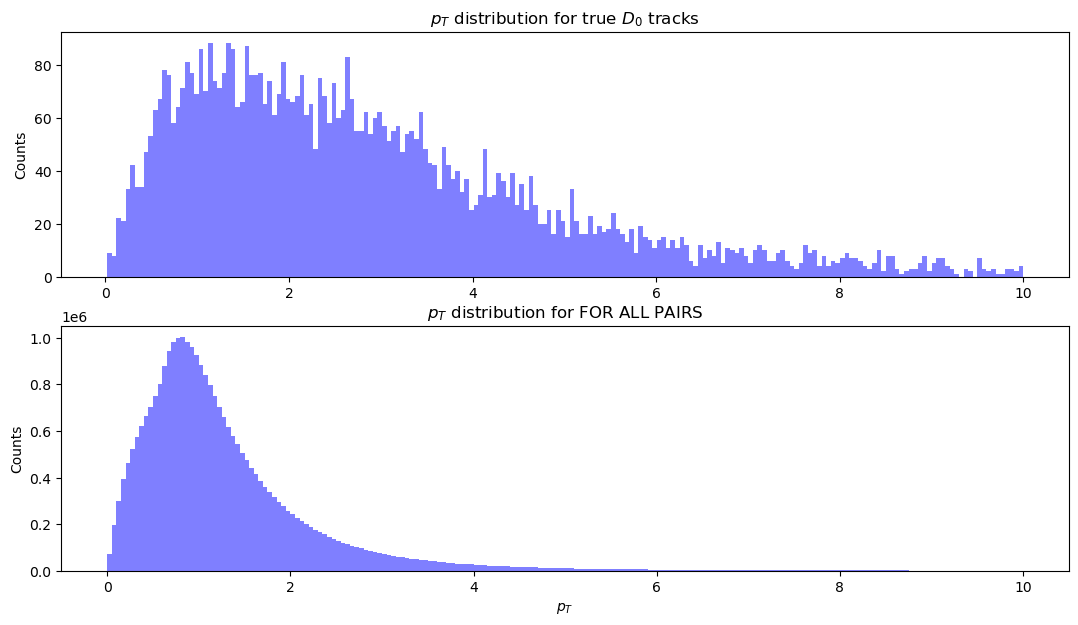

In [15]:
N_BINS = 200
fig, axs = plt.subplots( 2, 1, figsize=(13, 7)  )

# --- pT for TRUE D0 ---
data = final_results.loc[mask_true_d0, 'pt'].values
data = data [ data<10 ]
axs[0].hist( data, bins=N_BINS, color="blue", alpha=0.5, label=f"D^0" )
axs[0].set_ylabel("Counts")
axs[0].set_title("$p_T$ distribution for true $D_0$ tracks")

# --- pT FOR ALL PAIRS ---
data = final_results['pt'].values
data = data [ data<10 ]
axs[1].hist( data, bins=N_BINS, color="blue", alpha=0.5, label=f"D^0" )
axs[1].set_xlabel("$p_T$")
axs[1].set_ylabel("Counts")
axs[1].set_title("$p_T$ distribution for FOR ALL PAIRS")

plt.show()
del data

The $p_T$ windows like $[2-4]$ or $[3-6]$ could be useful to find the signal.

#### DECAY LENGTH

With the cut at 0.05 we keep 80.77% of original D_0s


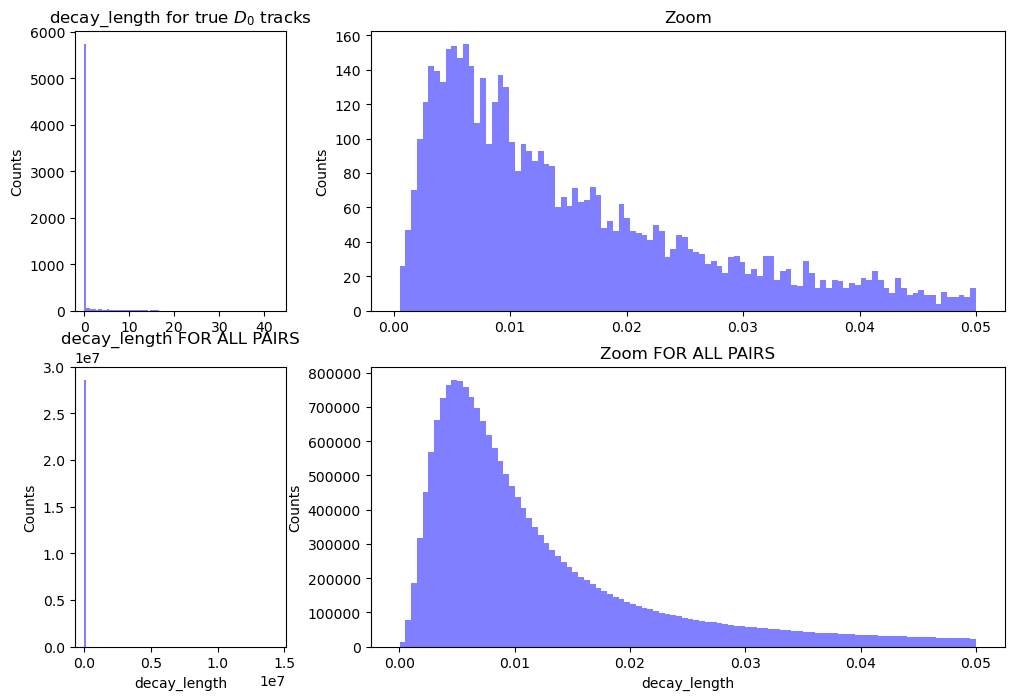

In [16]:
N_BINS = 100

# Layout con due colonne
zones = [
    ["total_D0", "zoom_D0"],
    ["total_all", "zoom_all"],
]

# Creazione della figura usando subplot_mosaic
fig, axes = plt.subplot_mosaic(
    zones,
    figsize=(12, 8),
    gridspec_kw={"width_ratios": [1, 3]}
)

# --- Plot decay length FOR TRUE D0 ---
data = final_results.loc[mask_true_d0, 'decay_length'].values
#data = data[ (data > -0.00015) & (data < 0.00015) ]
axes["total_D0"].hist( data, bins=N_BINS, color="blue", alpha=0.5, label=f"D^0")
axes["total_D0"].set_ylabel("Counts")
axes["total_D0"].set_title("decay_length for true $D_0$ tracks")

# --- Zoom FOR TRUE D0 ---
cut = 0.05
data = data[ data < cut ]
axes["zoom_D0"].hist( data, bins=100, color="blue", alpha=0.5, label=f"D^0")
axes["zoom_D0"].set_ylabel("Counts")
axes["zoom_D0"].set_title("Zoom")
print(f"With the cut at {cut} we keep {len(data)/d0_tot*100:.2f}% of original D_0s")

# --- Plot decay length FOR ALL PAIRS ---
data = final_results['decay_length'].values
#data = data[ (data > -0.00015) & (data < 0.00015) ]
axes["total_all"].hist( data, bins=N_BINS, color="blue", alpha=0.5, label=f"D^0")
axes["total_all"].set_ylabel("Counts")
axes["total_all"].set_xlabel("decay_length")
axes["total_all"].set_title("decay_length FOR ALL PAIRS")

# --- Zoom FOR ALL PAIRS ---
cut = 0.05
data = data[ data < cut ]
axes["zoom_all"].hist( data, bins=100, color="blue", alpha=0.5, label=f"D^0")
axes["zoom_all"].set_ylabel("Counts")
axes["zoom_all"].set_xlabel("decay_length")
axes["zoom_all"].set_title("Zoom FOR ALL PAIRS")

plt.show()
del data

# TRYING CUTS

In [34]:
# APPLYING CUTS:
data1 = final_results.loc[
    (final_results['neg_TOFka'] > -5) & (final_results['neg_TOFka'] < 5) & 
    (final_results['neg_TPCka'] > -2) & (final_results['neg_TPCka'] < 2) &
    (final_results['pt'] > 2) & (final_results['pt'] < 4) &
    (final_results['cos_pointing'] > 0.95),
    'inv_mass'   # chosen column
].values

data2 = final_results.loc[
    (final_results['neg_TOFka'] > -5) & (final_results['neg_TOFka'] < 5) & 
    (final_results['neg_TPCka'] > -2) & (final_results['neg_TPCka'] < 2) &
    (final_results['pt'] > 2) & (final_results['pt'] < 4) &
    (final_results['cos_pointing'] > 0.95),
    'anti_mass'   # chosen column
].values

data = np.concatenate( [data1, data2] )

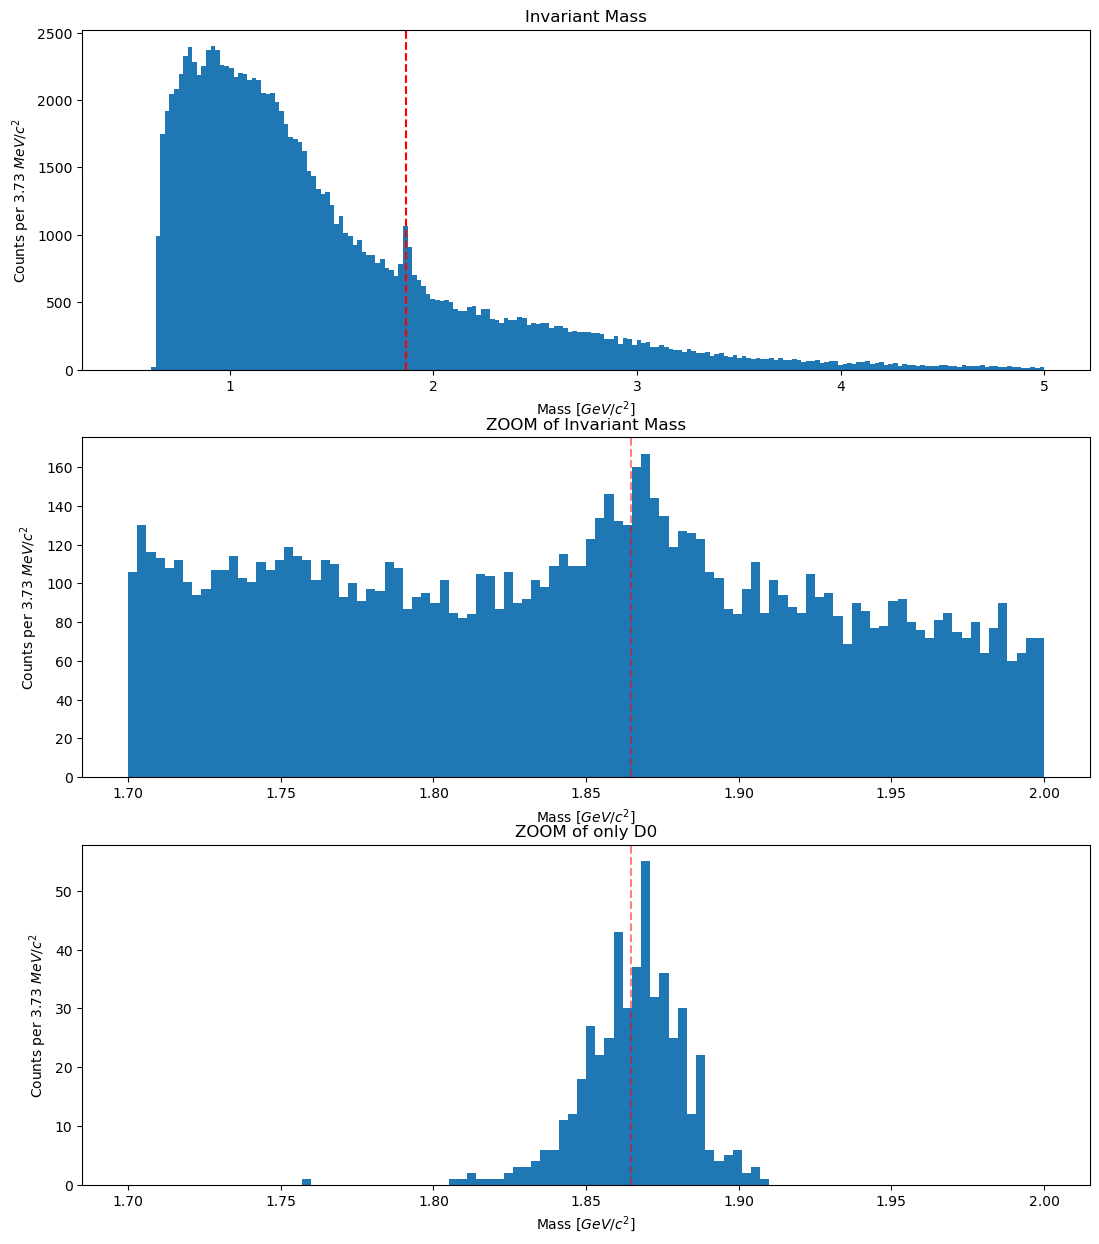

In [30]:
MIN_MASS, MAX_MASS = 0.8*m_d0, 1.2*m_d0
N_BINS = 200

num_of_plots = 3
fig, axs = plt.subplots( num_of_plots, 1, figsize=(13,5*num_of_plots)  )

# GLOBAL PLOT
axs[0].hist( data, bins=N_BINS, range=(0.5, 5))
axs[0].axvline(x=m_d0, color="red", ls='--')
axs[0].set_xlabel("Mass [$GeV/c^2$]")
axs[0].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
axs[0].set_title("Invariant Mass")
#axs[0].set_xticks( np.arange(0, 8) )

# ZOOM OF GLOBAL PLOT
axs[1].hist( data, bins=100, range=(1.7, 2))
axs[1].axvline(x=m_d0, color="red", ls='--', alpha=0.5)
axs[1].set_xlabel("Mass [$GeV/c^2$]")
axs[1].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
axs[1].set_title("ZOOM of Invariant Mass")
#axs[1].set_xticks( np.arange(0, 8) )

data1 = final_results.loc[
    mask_true_d0 &
    (final_results['neg_TOFka'] > -8) & (final_results['neg_TOFka'] < 8) & 
    (final_results['neg_TPCka'] > -2.5) & (final_results['neg_TPCka'] < 2.5) &
    (final_results['pt'] > 2) & (final_results['pt'] < 4) &
    (final_results['cos_pointing'] > 0.95),
    'inv_mass'   # chosen column
].values

# ZOOM OF GLOBAL PLOT
axs[2].hist( data1, bins=100, range=(1.7, 2))
axs[2].axvline(x=m_d0, color="red", ls='--', alpha=0.5)
axs[2].set_xlabel("Mass [$GeV/c^2$]")
axs[2].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
axs[2].set_title("ZOOM of only D0")
#axs[1].set_xticks( np.arange(0, 8) )

#plt.savefig("D0_Mass_MC.png")
plt.show()

In [39]:
# APPLYING CUTS:

data1 = final_results.loc[
    (final_results['inv_mass'] > 1.7) & (final_results['inv_mass'] < 2) & 
    (final_results['neg_TOFka'] > -5) & (final_results['neg_TOFka'] < 5) & 
    (final_results['neg_TPCka'] > -2) & (final_results['neg_TPCka'] < 2) &
    (final_results['pt'] > 2) & (final_results['pt'] < 4) &
    (final_results['cos_pointing'] > 0.95),
    'inv_mass'   # chosen column
].values
temp = len(data1)
print(f"Total ater cut: {temp}")
data1 = final_results.loc[
    mask_true_d0 &
    (final_results['neg_TOFka'] > -5) & (final_results['neg_TOFka'] < 5) & 
    (final_results['neg_TPCka'] > -2) & (final_results['neg_TPCka'] < 2) &
    (final_results['pt'] > 2) & (final_results['pt'] < 4) &
    (final_results['cos_pointing'] > 0.95),
    'inv_mass'   # chosen column
].values

print(f"Total ater cut, only true D0: {len(data1)}")
print(f"fraction: {len(data1)/temp*100:.2f}%")

# data2 = final_results.loc[
#     (final_results['neg_TOFka'] > -8) & (final_results['neg_TOFka'] < 8) & 
#     (final_results['neg_TPCka'] > -2.5) & (final_results['neg_TPCka'] < 2.5) &
#     (final_results['pt'] > 2) & (final_results['pt'] < 4) &
#     (final_results['cos_pointing'] > 0.95),
#     'anti_mass'   # chosen column
# ].values

# data = np.concatenate( [data1, data2] )

Total ater cut: 4666
Total ater cut, only true D0: 413
fraction: 8.85%


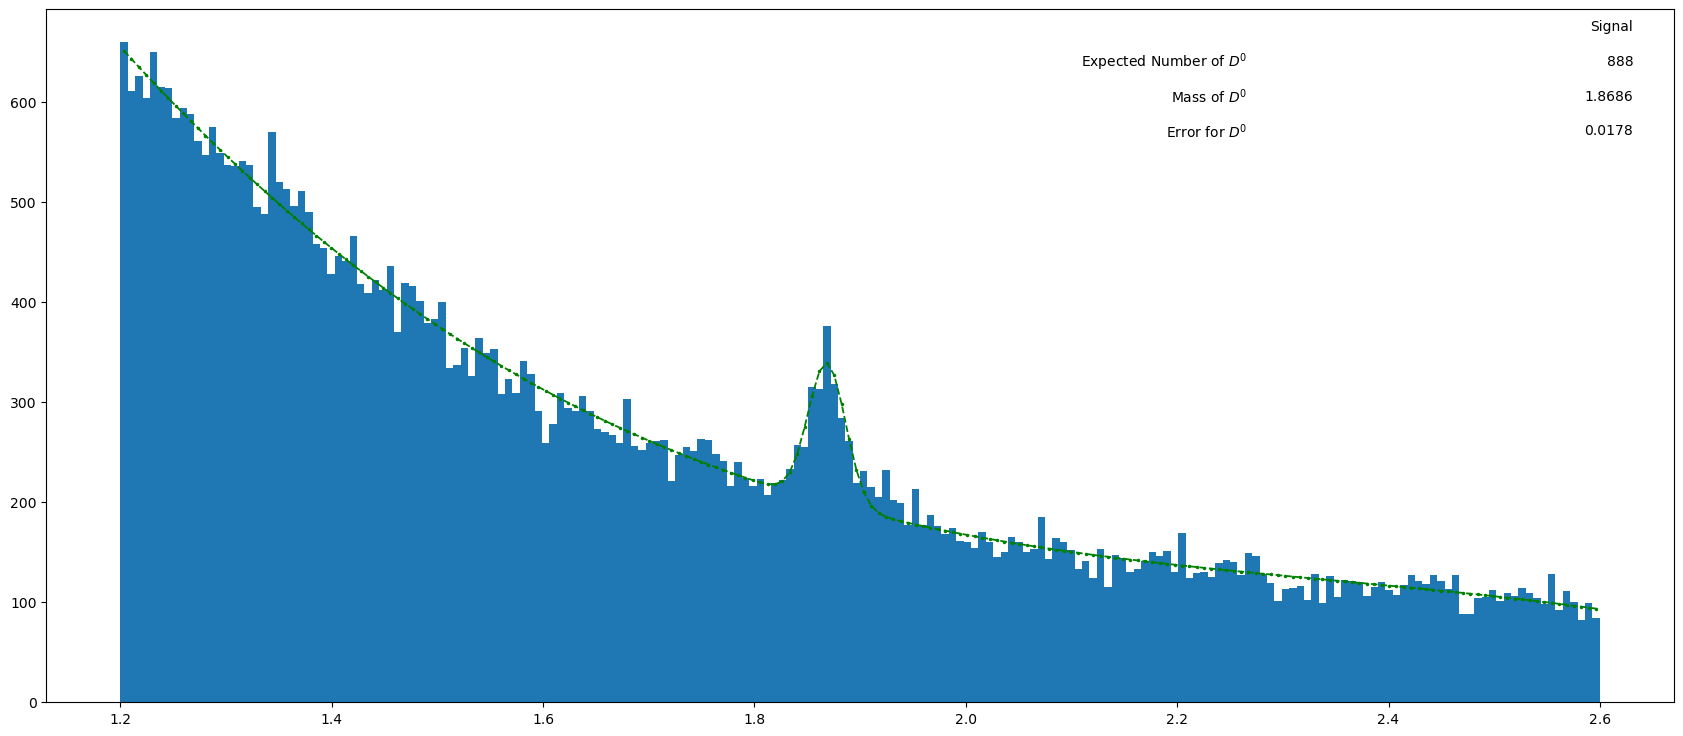

In [42]:
def both(x, N1, mu1, sigma1, N2, mu2, sigma2, a, b):
    return ( N1*norm.pdf(x, loc=mu1, scale=sigma1) + N2*norm.pdf(x, loc=mu2, scale=sigma2) +a*x +b  )

MIN_MASS, MAX_MASS = 1.2, 2.6
N_BINS = 200
binsize = (MAX_MASS - MIN_MASS)/N_BINS

signal_params = [50, m_d0, 0.05]
mirror_params = [1.132*50, m_d0, 0.1]
back_params = [133, 1000]

fig, ax = plt.subplots(figsize=(21,9))
both_counts, both_edges, _  = ax.hist( data, bins=N_BINS, range=(MIN_MASS, MAX_MASS))
both_centers = ( both_edges[:-1] + both_edges[1:] ) / 2.
both_fit_res = curve_fit( f = both, xdata=both_centers, ydata=both_counts, 
                            sigma = np.clip(np.sqrt(both_centers),a_min=1, a_max=1e+09),
                            p0 = [signal_params[0], signal_params[1], signal_params[2],
                                  mirror_params[0], mirror_params[1], mirror_params[2],
                                  back_params[0], back_params[1]    ]  )
both_params = both_fit_res[0]
ax.plot( both_centers, both( both_centers, both_params[0], both_params[1], both_params[2], both_params[3], both_params[4], \
                                           both_params[5],  both_params[6],  both_params[7]),color='green', marker='o', linestyle='dashed', \
                        linewidth=1.3, markersize=1.5, label = 'Both')

w3sigma = 0.997300
counts_from_fit = both_params[0]*w3sigma/binsize
mass_from_fit = both_params[1]
sigma_from_fit = both_params[2]

ax.table(
    cellText = [ [f"{counts_from_fit:.0f}"], [f"{mass_from_fit:.4f}"], [f"{sigma_from_fit:.4f}"] ],
    rowLabels = [ r'Expected Number of $D^0$', r'Mass of $D^0$', r'Error for $D^0$'],
    colLabels = [ 'Signal' ],
    colLoc = "right",
    bbox = [ 0.75, 0.8, 0.25, 0.2 ],
    edges = 'open',
    rowLoc = 'right'
    )
plt.show()



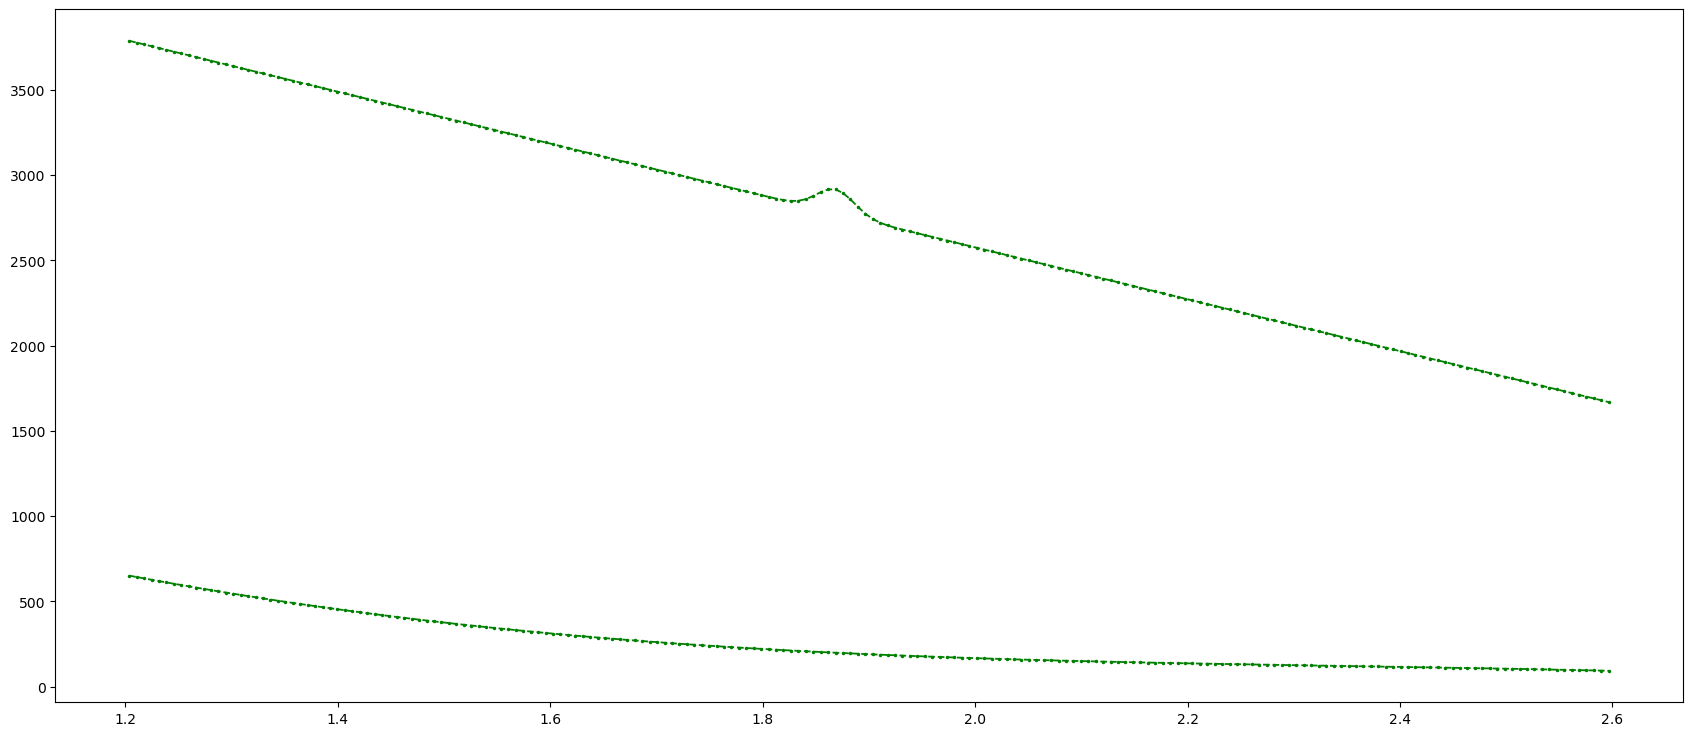

In [50]:
fig, ax = plt.subplots(figsize=(21,9))
ax.plot( both_centers, both_params[0]*norm.pdf(x=both_centers, loc= both_params[1], scale=both_params[2] ) + \
         both_params[6]*both_centers + both_params[7] ,color='green', marker='o', linestyle='dashed', \
                        linewidth=1.3, markersize=1.5, label = 'Both')

ax.plot( both_centers, both_params[3]*norm.pdf(x=both_centers, loc= both_params[4], scale=both_params[5] ) + \
         both_params[6]*both_centers + both_params[7] ,color='green', marker='o', linestyle='dashed', \
                        linewidth=1.3, markersize=1.5, label = 'Both')

plt.show()